----------------------------------------
  Chargement...
  Shape charg  : (4372, 123)
  Correction des aberrants...
  Imputation des NaN...
   S paration X / y...
  Train / Test split...
  Train : (3497, 122) | Test : (875, 122)
  Suppression colonnes fuite...
  [CRITICAL] Colonnes fuite supprimees: 19 colonnes
    - Time-based (HIGH leakage): ['firstpurchasedaysago', 'monetaryperday', 'customertenuredays', 'monetaryperday_log', 'tenureratio', 'recency']
  Suppression des features corr l es...
  Colonnes fortement corr l es (> 0.5) supprim es : ['monetarytotal', 'avgquantitypertransaction', 'weekendpurchaseratio', 'uniqueproducts', 'negativequantitycount', 'totaltransactions', 'uniqueinvoices', 'avgbasketvalue', 'purchaseintensity', 'productdiversityratio', 'avgbasketvalue_log', 'returnimpact_log']
   Encodage (get_dummies)...
  Apr s encodage   91 colonnes
  X_train: (3497, 91), X_test: (875, 91)
  Nettoyage inf / NaN r siduels...
  Scaling (apr s encodage)...
  Scaler fit sur 22 colo

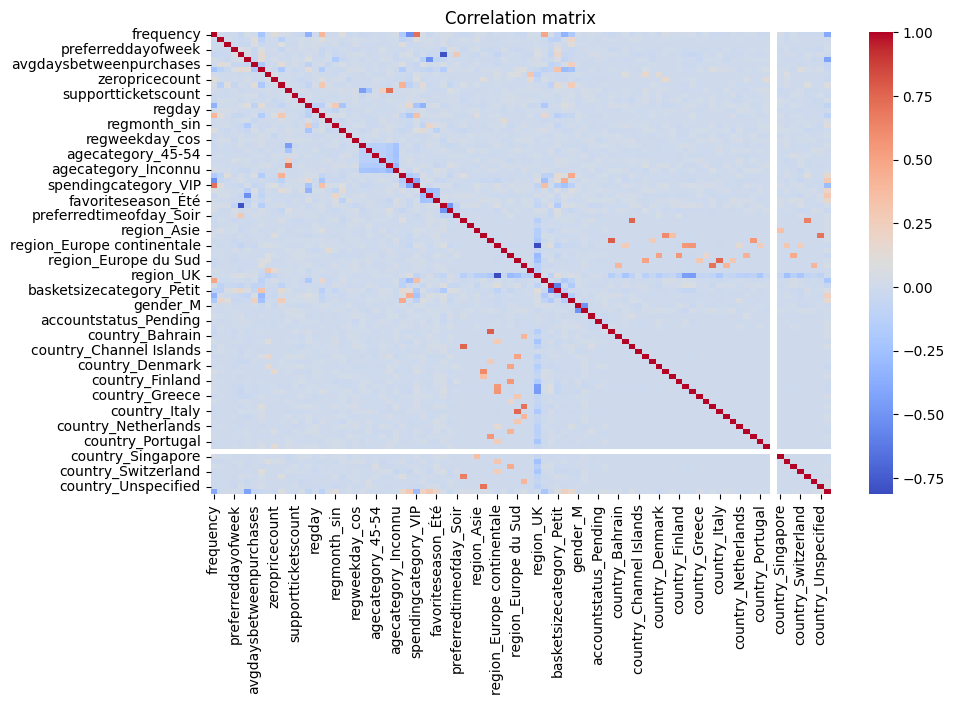

Accuracy random test: 0.5428571428571428
          frequency   monetaryavg   monetarystd  preferreddayofweek  \
count  3.497000e+03  3.497000e+03  3.497000e+03        3.497000e+03   
mean  -5.130456e-17 -3.047796e-18 -7.111523e-18       -4.978066e-17   
std    1.000143e+00  1.000143e+00  1.000143e+00        1.000143e+00   
min   -8.895718e-01 -3.146131e+01 -3.506133e-02       -1.367671e+00   
25%   -8.895718e-01 -1.368399e-01 -3.296706e-02       -8.231871e-01   
50%   -2.851159e-01 -9.455335e-02 -3.156892e-02       -2.787034e-01   
75%    6.215681e-01 -4.510005e-02 -2.809448e-02        8.102640e-01   
max    2.132708e+00  2.791553e+01  4.572501e+01        1.899231e+00   

       preferredhour  preferredmonth  avgdaysbetweenpurchases  \
count   3.497000e+03    3.497000e+03             3.497000e+03   
mean    1.381667e-16    4.063727e-17            -2.844609e-17   
std     1.000143e+00    1.000143e+00             1.000143e+00   
min    -2.385465e+00   -1.902757e+00            -3.078621e-

In [3]:

import sys
sys.path.append('../src')
from preprocessing import preprocess_pipeline

X_train, X_test, y_train, y_test, X_train_smote, y_train_smote, scaler = preprocess_pipeline(
    '../data/processed/step3_feature_engineering.csv'
)

# ✔ Vérification distribution
print("Train distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

# ✔ Correlation
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_check = pd.concat([X_train, y_train], axis=1)

plt.figure(figsize=(10,6))
sns.heatmap(df_check.corr(), cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

# ✔ Colonnes suspectes
for col in X_train.columns:
    if "churn" in col.lower():
        print("⚠️ colonne suspecte :", col)

# ✔ Test random
from sklearn.metrics import accuracy_score
import numpy as np

y_random = np.random.permutation(y_test)

print("Accuracy random test:",
      accuracy_score(y_random, y_test))

# ✔ Statistiques
print(X_train.describe())


In [4]:
import pandas as pd

# Charger les données (raw ou après encoding mais avant SMOTE)
df = pd.read_csv('../data/processed/step3_feature_engineering.csv')

# Séparer X / y
X = df.drop(columns=['Churn'])
y = df['Churn']

# Pour vérifier la corrélation uniquement sur les colonnes numériques
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
corr_matrix = pd.concat([X[numeric_cols], y], axis=1).corr()['Churn'].sort_values(ascending=False)

# Afficher les colonnes très corrélées
print("⚠ Colonnes fortement corrélées avec Churn (>0.9) :")
print(corr_matrix[corr_matrix > 0.9])


# Colonnes object avant encoding
cat_cols = df.select_dtypes(include=['object']).columns
print("Colonnes catégorielles :", cat_cols)

# Vérifier leur relation avec Churn
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(df[col], y))

from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    x = le.fit_transform(df[col])
    chi, p = chi2(x.reshape(-1,1), df['Churn'])
    print(f"{col}: chi2={chi[0]:.2f}, p-value={p[0]:.5f}")

import seaborn as sns
import matplotlib.pyplot as plt

# Exemple pour RFMSegment
sns.countplot(x='RFMSegment', hue='Churn', data=df)
plt.title("Distribution Churn selon RFMSegment")
plt.show()

# Même pour CustomerType ou LoyaltyLevel
sns.countplot(x='CustomerType', hue='Churn', data=df)
plt.show()



KeyError: "['Churn'] not found in axis"

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

model = RandomForestClassifier(random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

print("F1 scores:", scores)
print("Mean F1:", np.mean(scores))


F1 scores: [1.         1.         0.995671   0.99784017 1.        ]
Mean F1: 0.9987022336914346
